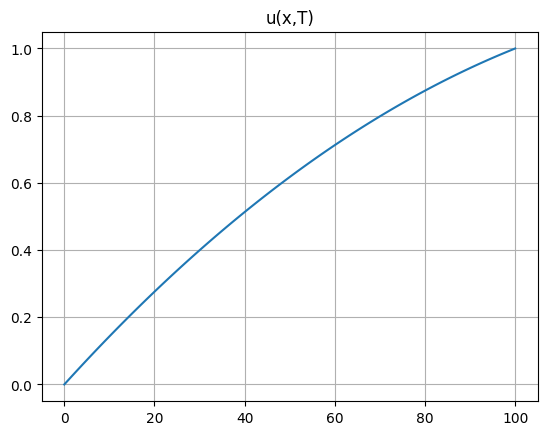

In [ ]:
import numpy as np
import matplotlib.pyplot as plt




# @title Лабораторная №2
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
# длина стержня в сетке
l = 1
# кол-во узлов в сетке
n = 1000

L = 1.0
T = 1.0
M = 100
N = 100
h = L / N
tau = T / M

# Метод прогонки
A = 1 / h**2
B = 1/tau + 2/h**2 
C = 1 / h **2

def func(x):
    return 1.0


T1=np.zeros((M+1, N+1), 'float')  # Матрица для температуры в неявной схеме
for i in range(0,N+1): T1[0,i] = 0.0
for j in range(0, M):
    T1[j,N] = 1.0
    T1[j,0] = 0.0
    A=1 / h**2; B=1/tau + 2/h**2 + 0.1; C=1 / h **2
    alpha = np.zeros((N+1)); beta = np.zeros((N+1)); 
    alpha[1] = 0.0; beta[1] = 0.0
    
    for i in range(1, N):                                                               # находим прогоночные коэффициенты прямой ход
        alpha[i+1]= ( -C/(A*alpha[i]-B) )
        beta[i+1] = ( (-T1[j][i]/tau - func(i*h) -A*beta[i]) / (A*alpha[i]-B) )
    T1[j+1,N] = 1.0
    for i in reversed(range(0, N)):                                                     # проходимся по узлам стер|жня 0 до n - 1 обратный ход
        T1[j+1][i] = alpha[i+1]* T1[j+1][i+1] + beta[i+1]

plt.title("u(x,T)")
plt.grid()
plt.plot(T1[-1])

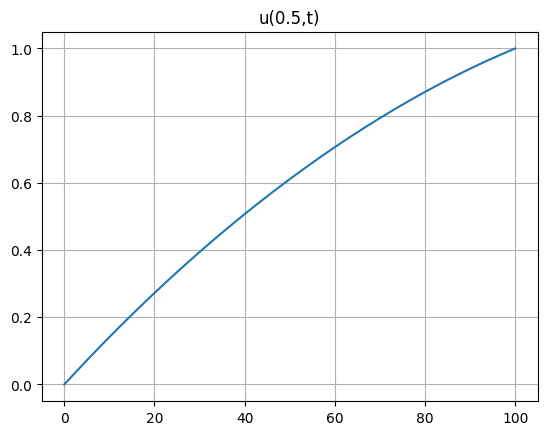

In [165]:
for i in range(N):
    if(i*h == 0.5):
        plt.title("u(0.5,t)")
        plt.grid()
        plt.plot(T1[:][i])
plt.show()

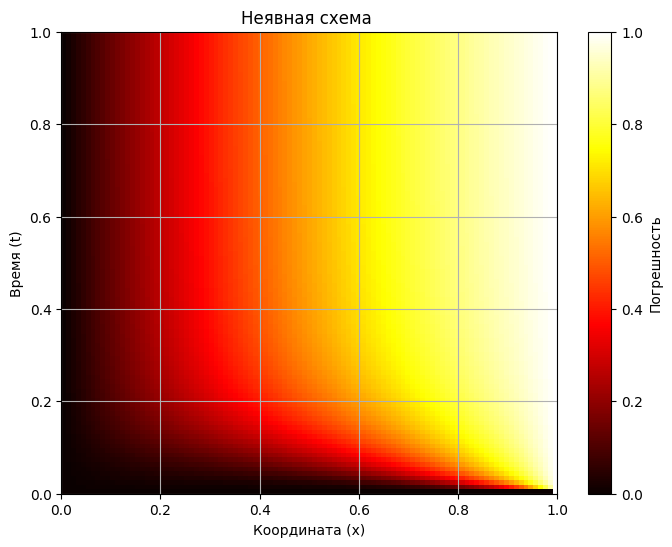

In [166]:
fig, ax1 = plt.subplots(1, 1,figsize=(8, 6))

im1 = ax1.imshow(T1, extent=[ 0, L, 0, T], aspect='auto', cmap='hot', origin='lower', interpolation='nearest')
ax1.set_ylabel("Время (t)"); ax1.set_xlabel("Координата (x)"); ax1.set_title("Неявная схема "); ax1.grid(True)
fig.colorbar(im1, ax=ax1, orientation='vertical', label='Погрешность')

plt.show()

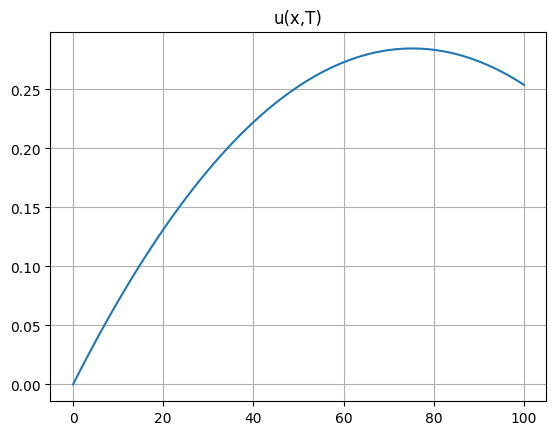

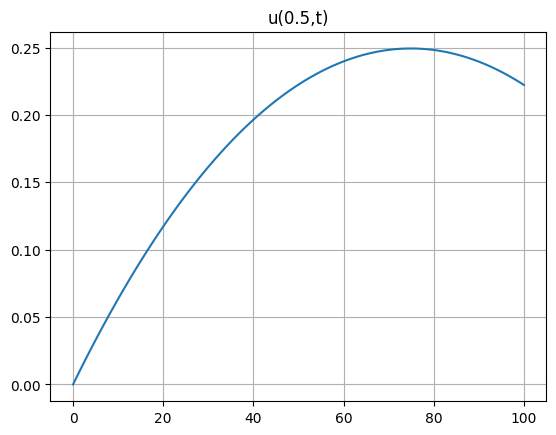

In [3]:
# @title Лабораторная №2
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

L = 1.0
T = 1.0
M = 100
N = 100
h = L / N
tau = T / M

# Метод прогонки
A = 1 / h**2
B = 1 / tau + 2 / h**2 - 0.1
C = 1 / h **2

def func(x):
    return 1.0


T1=np.zeros((M+1, N+1), 'float')  # Матрица для температуры в неявной схеме
for i in range(0,N+1): 
    T1[0,i] = 0.0
for j in range(0, M):
    T1[j,0] = 0.0
    alpha = np.zeros((N+1))
    beta = np.zeros((N+1)) 
    alpha[1] = 0.0; beta[1] = 0.0
    
    for i in range(1, N):                                                               # находим прогоночные коэффициенты прямой ход
        alpha[i+1]= ( -C/(A*alpha[i]-B) )
        beta[i+1] = ( (-T1[j][i]/tau - func(i*h) -A*beta[i]) / (A*alpha[i]-B) )
    T1[j+1,N] = (tau * h + beta[N])/(1 - alpha[N] + h)
    for i in reversed(range(0, N)):                                                     # проходимся по узлам стер|жня 0 до n - 1 обратный ход
        T1[j+1][i] = alpha[i+1]* T1[j+1][i+1] + beta[i+1]

plt.title("u(x,T)")
plt.grid()
plt.plot(T1[-1])
plt.show()
for i in range(N):
    if(i*h == 0.5):
        plt.title("u(0.5,t)")
        plt.grid()
        plt.plot(T1[:][i])
plt.show()

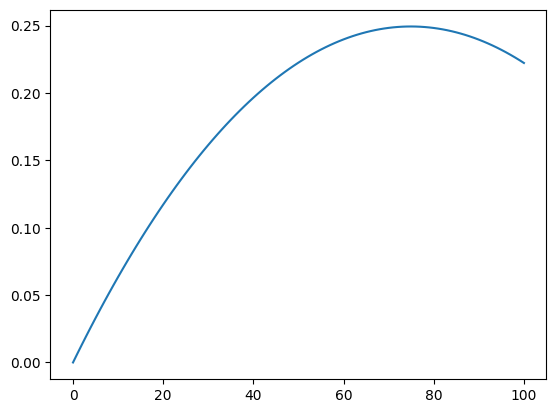

In [2]:
plt.plot(T1[:][N//2])

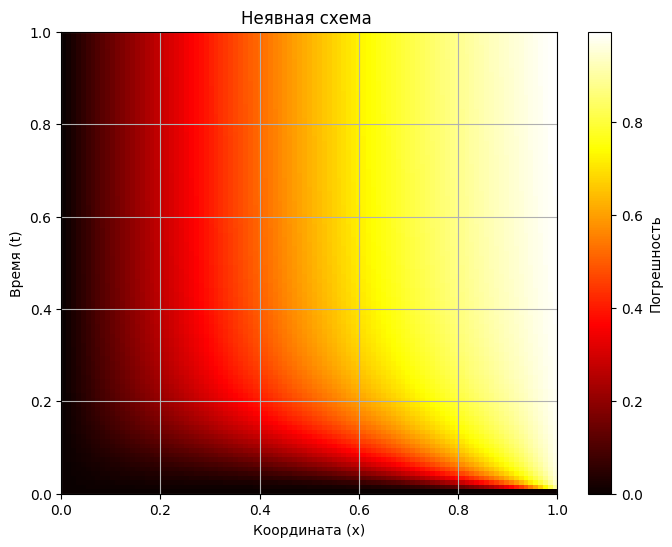

In [169]:
fig, ax1 = plt.subplots(1, 1,figsize=(8, 6))

im1 = ax1.imshow(T1, extent=[ 0, L, 0, T], aspect='auto', cmap='hot', origin='lower', interpolation='nearest')
ax1.set_ylabel("Время (t)"); ax1.set_xlabel("Координата (x)"); ax1.set_title("Неявная схема "); ax1.grid(True)
fig.colorbar(im1, ax=ax1, orientation='vertical', label='Погрешность')

plt.show()